In [119]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=a4f88198aa36aad18d33ce66aec81b3d6fd00f6460e42f2dfdead06babd8efee
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gpiosenka/coffee-bean-dataset-resized-224-x-224")

print("Path to dataset files:", path)

100%|██████████| 144M/144M [00:01<00:00, 144MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224/versions/1


In [120]:
import os
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import trange
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, ReLU, Input
from keras.callbacks import EarlyStopping
import torchvision.models as models
from efficientnet_pytorch import EfficientNet
sns.set()

In [3]:
os.listdir("/root/.cache/kagglehub/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224/versions/1")

['train', 'Coffee Bean.csv', 'test']

In [4]:
train_dir = "/root/.cache/kagglehub/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224/versions/1/train"
test_dir = "/root/.cache/kagglehub/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224/versions/1/test"

In [71]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

In [72]:
test_valid_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

In [73]:
train_ds = ImageFolder(train_dir, transform = train_transform)
test_ds = ImageFolder(test_dir, transform = test_valid_transform)

In [74]:
targets = np.array(train_ds.targets)

In [75]:
train_idx, valid_idx, train_targets, valid_targets = train_test_split(
    np.arange(len(targets)),
    targets,
    test_size = 0.1,
    stratify = targets,
    random_state = 101
)

In [76]:
train_dataset = Subset(train_ds, train_idx)
valid_dataset = Subset(train_ds, valid_idx)
test_dataset = test_ds

In [77]:
valid_dataset.dataset.transform = test_valid_transform

In [78]:
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, num_workers = 4)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False, num_workers = 4)
valid_loader = DataLoader(valid_dataset, batch_size = 64, shuffle = False, num_workers = 4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [79]:
print(f"Trainig set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Validation set size: {len(valid_dataset)}")
print("\n")
print(f"Number of classes: {len(train_dataset.dataset.classes)}")
print(f"Classes: {train_dataset.dataset.classes}")

Trainig set size: 1080
Test set size: 400
Validation set size: 120


Number of classes: 4
Classes: ['Dark', 'Green', 'Light', 'Medium']


In [80]:
num_classes = len(train_dataset.dataset.classes)
num_classes

4

In [81]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [82]:
def plot_results(train_accs, train_losses, valid_accs, valid_losses):
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))
    xs = np.arange(1, len(train_accs) + 1, 1)
    axes[0].plot(xs, train_accs, label = "Training Accuracy")
    axes[0].plot(xs, valid_accs, label = "Validation Accuracy")
    axes[0].set_title("Training accuracy vs Validation accuracy", fontsize = 15)
    axes[0].set_xlabel("Epoch", fontsize = 10)
    axes[0].set_ylabel("Accuracy", fontsize = 10)
    axes[0].set_xticks(xs)
    axes[0].legend()

    axes[1].plot(xs, train_losses, label = "Training Loss")
    axes[1].plot(xs, valid_losses, label = "Validation Loss")
    axes[1].set_title("Training loss vs Validation loss", fontsize = 15)
    axes[1].set_xlabel("Epoch", fontsize = 10)
    axes[1].set_ylabel("Loss", fontsize = 10)
    axes[1].set_xticks(xs)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [138]:
def train_step(model, criterion, optimizer, dataloader, device = device):
    model.train()
    total_loss = 0
    total_acc = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
    return total_loss / len(dataloader), 100 * total_acc / len(dataloader.dataset)

In [139]:
def valid_step(model, criterion, dataloader, device = device):
    model.eval()
    total_loss = 0
    total_acc = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            total_loss += criterion(preds, y).item()
            total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
    return total_loss / len(dataloader), 100 * total_acc / len(dataloader.dataset)

In [140]:
def train_model(model, n_epochs, optimizer, train_loader, valid_loader, patience = 2, device = device):
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []
    patience_count = 0
    best_loss = float("inf")
    criterion = nn.CrossEntropyLoss()
    scheduler = ReduceLROnPlateau(optimizer, factor = 0.5, mode = "min", patience = 2)
    pbar = trange(n_epochs)
    for epoch in pbar:
        train_loss, train_acc = train_step(model, criterion, optimizer, train_loader, device = device)
        valid_loss, valid_acc = valid_step(model, criterion, valid_loader, device = device)
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)
        pbar.set_description(f"Train Loss: {train_loss:.3f} | Valid Loss: {valid_loss:.3f} | Train Acc: {train_acc:.3f} | Valid Acc: {valid_acc:.3f}")
        scheduler.step(valid_loss)
        if valid_loss < best_loss:
            best_loss = valid_loss
            patience_count = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_count += 1
            if patience_count > patience:
                model.load_state_dict(torch.load("best_model.pt"))
                break
    plot_results(train_accs, train_losses, valid_accs, valid_losses)
    return {"train_acc": train_acc, "train_loss": train_loss, "valid_acc": valid_acc, "valid_loss": valid_loss}

In [ ]:
class Model1(nn.Module):
    def __init__(self, num_classes):
        super(Model1, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 256, kernel_size = 3, padding = 1, stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),

            nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, padding = 1, stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),

            nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, padding = 1, stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),

            nn.Flatten(),

            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Train Loss: 0.158 | Valid Loss: 0.085 | Train Acc: 94.352 | Valid Acc: 96.667:  50%|█████     | 10/20 [00:38<00:38,  3.82s/it]


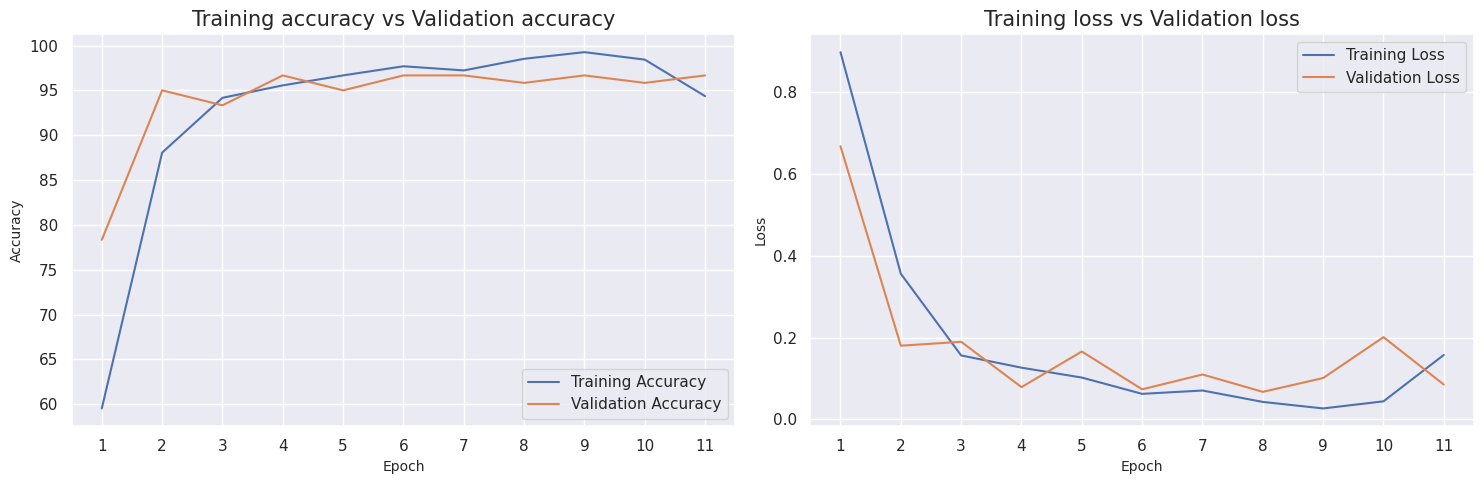

In [ ]:
model1 = Model1(num_classes = num_classes).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr = 0.001)
results = train_model(model1, 20, optimizer, train_loader, valid_loader, device = device)

In [ ]:
class Model2(nn.Module):
    def __init__(self, num_classes):
        super(Model2, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 256, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Dropout(0.5),

            nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Dropout(0.5),

            nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Dropout(0.5),

            nn.Flatten(),

            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Train Loss: 0.079 | Valid Loss: 0.177 | Train Acc: 97.407 | Valid Acc: 96.667:  45%|████▌     | 9/20 [00:36<00:44,  4.03s/it]


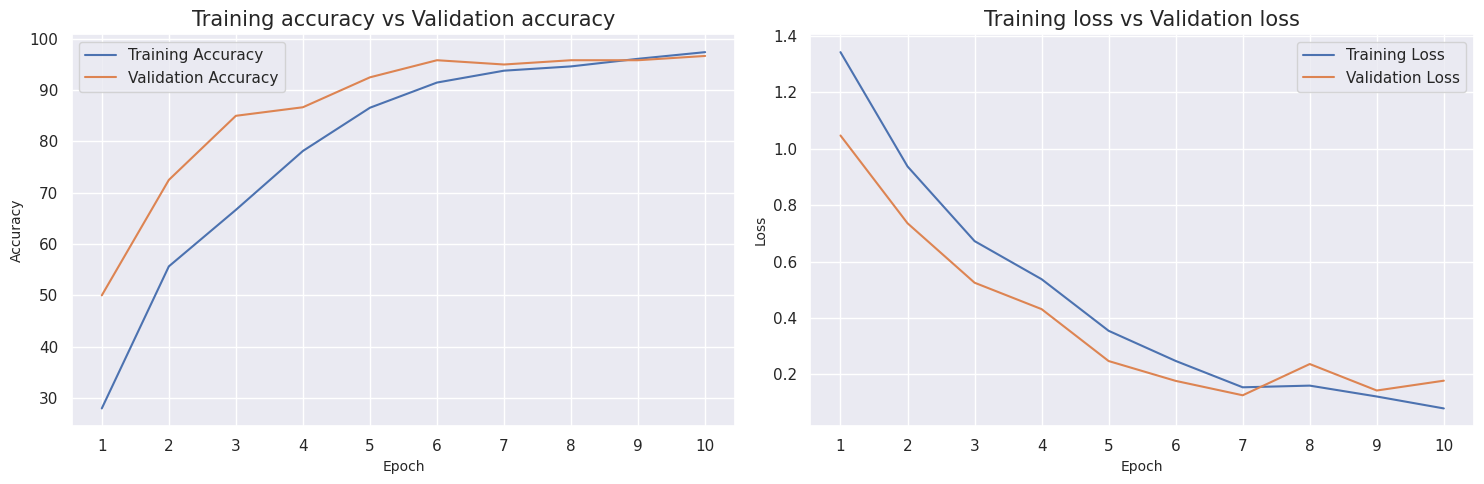

In [ ]:
model2 = Model2(num_classes = num_classes).to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr = 0.001)
result = train_model(model2, 20, optimizer, train_loader, valid_loader, device = device)

In [ ]:
class Model3(nn.Module):
  def __init__(self, num_classes):
    super(Model3, self).__init__()
    self.network = nn.Sequential(
        nn.Conv2d(in_channels = 3, out_channels = 256, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(256),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),

        nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),

        nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),

        nn.Flatten(),

        nn.Linear(64 * 16 * 16, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),

        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),

        nn.Linear(128, num_classes)
    )

  def forward(self, x):
    return self.network(x)

Train Loss: 0.070 | Valid Loss: 0.152 | Train Acc: 97.315 | Valid Acc: 92.500:  50%|█████     | 10/20 [00:51<00:51,  5.18s/it]


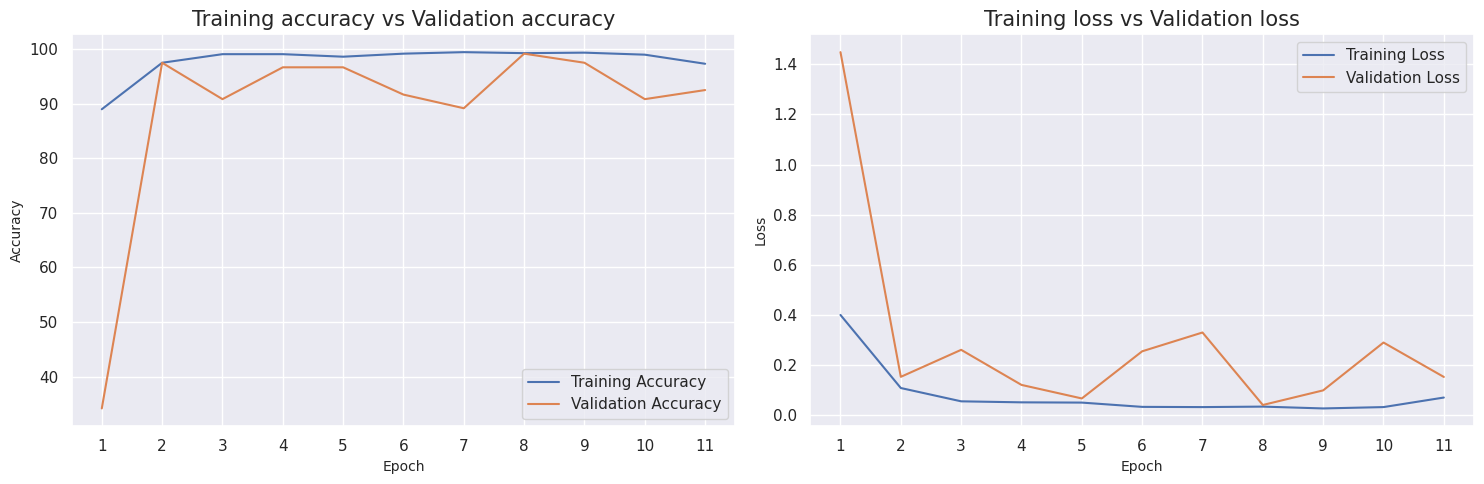

In [ ]:
model3 = Model3(num_classes = num_classes).to(device)
optimizer = torch.optim.Adam(model3.parameters(), lr = 0.001)
results = train_model(model3, 20, optimizer, train_loader, valid_loader, device = device)

In [ ]:
class Model4(nn.Module):
  def __init__(self, num_classes):
    super(Model4, self).__init__()
    self.network = nn.Sequential(
        nn.Conv2d(in_channels = 3, out_channels = 256, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(256),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Flatten(),

        nn.Linear(64 * 16 * 16, 256),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(128, num_classes)
    )

  def forward(self, x):
    return self.network(x)

Train Loss: 0.134 | Valid Loss: 0.067 | Train Acc: 95.093 | Valid Acc: 98.333:  55%|█████▌    | 11/20 [00:59<00:48,  5.41s/it]


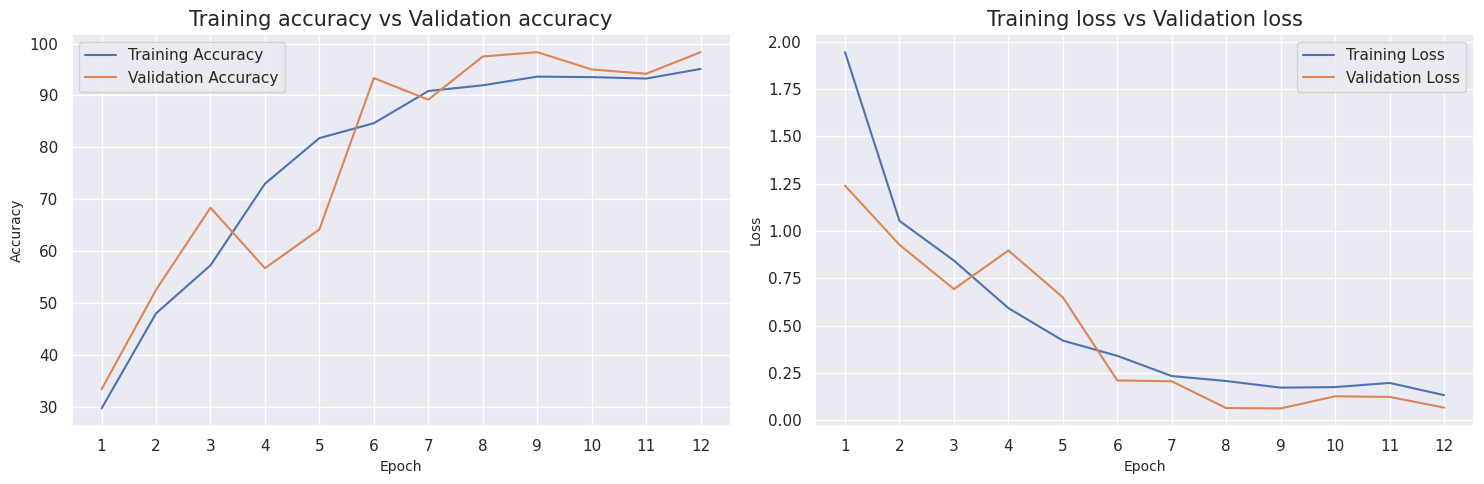

In [ ]:
model4 = Model4(num_classes = num_classes).to(device)
optimizer = torch.optim.Adam(model4.parameters(), lr = 0.001)
results = train_model(model4, 20, optimizer, train_loader, valid_loader, device = device)

In [ ]:
class Model4(nn.Module):
  def __init__(self, num_classes):
    super(Model4, self).__init__()
    self.network = nn.Sequential(
        nn.Conv2d(in_channels = 3, out_channels = 256, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(256),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, padding = 1, stride = 1),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Flatten(),

        nn.Linear(64 * 16 * 16, 512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    return self.network(x)

Train Loss: 0.205 | Valid Loss: 0.191 | Train Acc: 93.056 | Valid Acc: 94.167:  40%|████      | 8/20 [01:21<02:01, 10.14s/it]


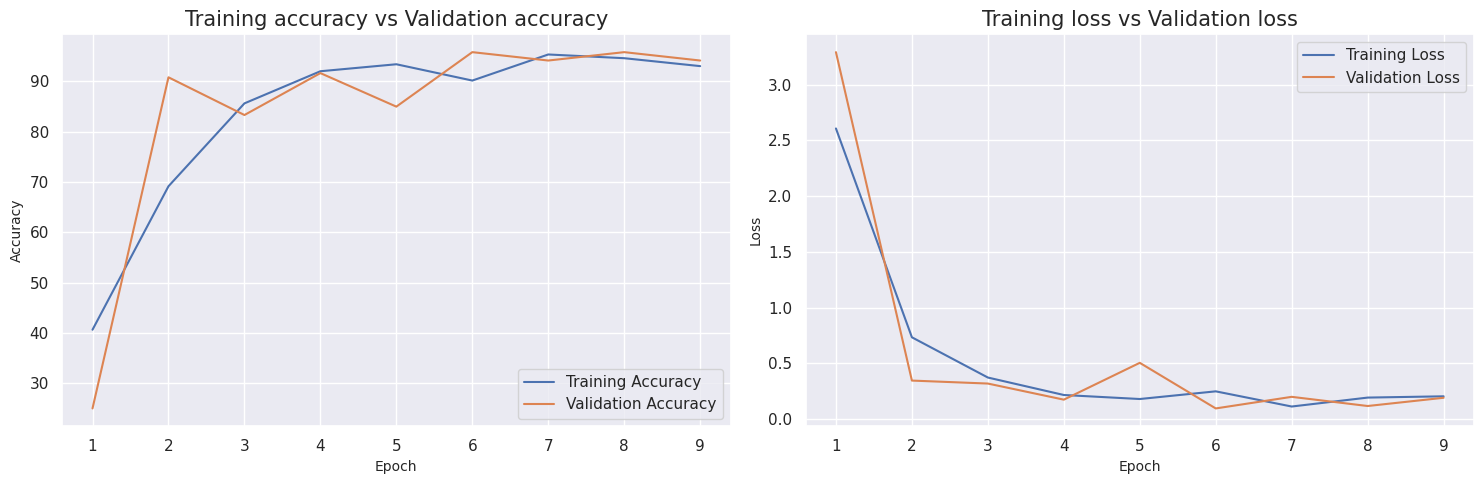

In [ ]:
model5 = Model5(num_classes = num_classes).to(device)
optimizer = torch.optim.Adam(model5.parameters(), lr = 0.001)
results = train_model(model5, 20, optimizer, train_loader, valid_loader, device = device)

In [61]:
def cm(y_preds, y_true):
  plt.figure(figsize = (7, 5))
  sns.heatmap(confusion_matrix(y_true, y_preds), annot = True, cbar = True, square = True, annot_kws = {"size": 15}, fmt = "d", cmap = "Blues")
  plt.title("Confusion Matrix", fontsize = 15)
  plt.xlabel("Predicted", fontsize = 10)
  plt.ylabel("Truth", fontsize = 10)
  plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Test Loss: 0.074 | Test Accuracy: 97.500


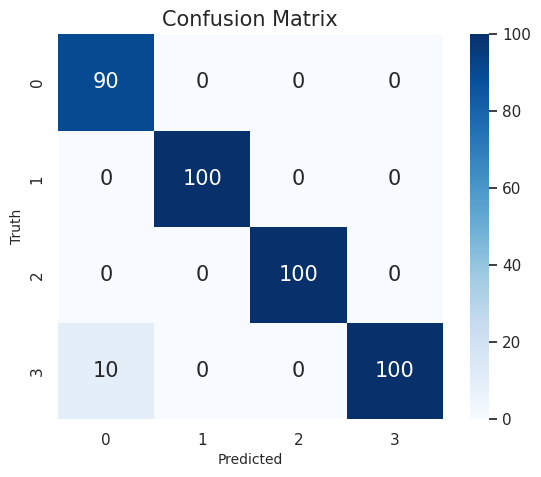

In [ ]:
model5.eval()
criterion = nn.CrossEntropyLoss()
total_loss = 0
total_acc = 0
y_preds = []
y_true = []
with torch.no_grad():
  for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    preds = model5(x)
    total_loss += criterion(preds, y).item()
    total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
    y_preds.extend(preds.argmax(1).cpu().numpy())
    y_true.extend(y.cpu().numpy())
  test_loss = total_loss / len(test_loader)
  test_acc = 100 * total_acc / len(test_loader.dataset)
  print(f"Test Loss: {test_loss:.3f} | Test Accuracy: {test_acc:.3f}")
  cm(y_true, y_preds)

In [ ]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       0.91      1.00      0.95       100

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.97       400



In [5]:
train_ds2 = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = (128, 128),
    batch_size = 64,
    shuffle = True,
    seed = 101
)

Found 1200 files belonging to 4 classes.


In [6]:
test_ds2 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = (128, 128),
    batch_size = 64,
    shuffle = False,
    seed = 101
)

Found 400 files belonging to 4 classes.


In [7]:
def train_val_split(data):
  train_data2 = data.take(int(len(data) * 0.8))
  valid_data2 = data.skip(int(len(data) * 0.8)).take(int(len(data) * 0.2))
  return train_data2, valid_data2

In [8]:
train_data2, valid_data2 = train_val_split(train_ds2)

In [9]:
print(f"Train size: {len(train_data2)} batches")
print(f"Test size: {len(test_ds2)} batches")
print(f"Validation size: {len(valid_data2)} batches")

Train size: 15 batches
Test size: 7 batches
Validation size: 3 batches


In [10]:
def normalize_image(image, label):
  image = tf.cast(image, tf.float32) / 255.0
  return image, label

In [11]:
train_data = train_data2.map(normalize_image)
valid_data = valid_data2.map(normalize_image)
test_data = test_ds2.map(normalize_image)

In [26]:
tf_model = Sequential()

In [27]:
tf_model.add(Input(shape = (128, 128, 3)))

tf_model.add(Conv2D(256, (3, 3), padding = "same"))
tf_model.add(MaxPooling2D(pool_size = (2, 2)))
tf_model.add(ReLU())
tf_model.add(Dropout(0.5))

tf_model.add(Conv2D(128, (3, 3), padding = "same"))
tf_model.add(MaxPooling2D(pool_size = (2, 2)))
tf_model.add(ReLU())
tf_model.add(Dropout(0.5))

tf_model.add(Conv2D(64, (3, 3), padding = "same"))
tf_model.add(MaxPooling2D(pool_size = (2, 2)))
tf_model.add(ReLU())
tf_model.add(Dropout(0.5))

tf_model.add(Flatten())

tf_model.add(Dense(256, activation = "relu"))
tf_model.add(Dropout(0.5))

tf_model.add(Dense(128, activation = "relu"))
tf_model.add(Dropout(0.5))

tf_model.add(Dense(4, activation = "softmax"))

In [28]:
tf_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,603,972 (17.56 MB)

 Trainable params: 4,603,972 (17.56 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
tf_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ["accuracy"]
)

In [30]:
early_stopping = EarlyStopping(monitor = "val_loss", patience = 2)

In [31]:
history = tf_model.fit(train_data, validation_data = valid_data, epochs = 40, callbacks = [early_stopping])

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 309ms/step - accuracy: 0.2597 - loss: 1.5873 - val_accuracy: 0.2135 - val_loss: 1.3863
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step - accuracy: 0.2852 - loss: 1.3858 - val_accuracy: 0.3125 - val_loss: 1.3844
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 345ms/step - accuracy: 0.2870 - loss: 1.3687 - val_accuracy: 0.5625 - val_loss: 1.1997
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 259ms/step - accuracy: 0.5117 - loss: 1.0905 - val_accuracy: 0.6615 - val_loss: 0.8116
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 349ms/step - accuracy: 0.5859 - loss: 0.8680 - val_accuracy: 0.6615 - val_loss: 0.8212
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 349ms/step - accuracy: 0.6741 - loss: 0.7401 - val_accuracy: 0.7344 - val_loss: 0.6647
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.7630 - loss: 0.5484 - val_accuracy: 0.7969 - val_loss: 0.6318
Epoch 8/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.7881 - loss: 0.5235 - val_accuracy: 0

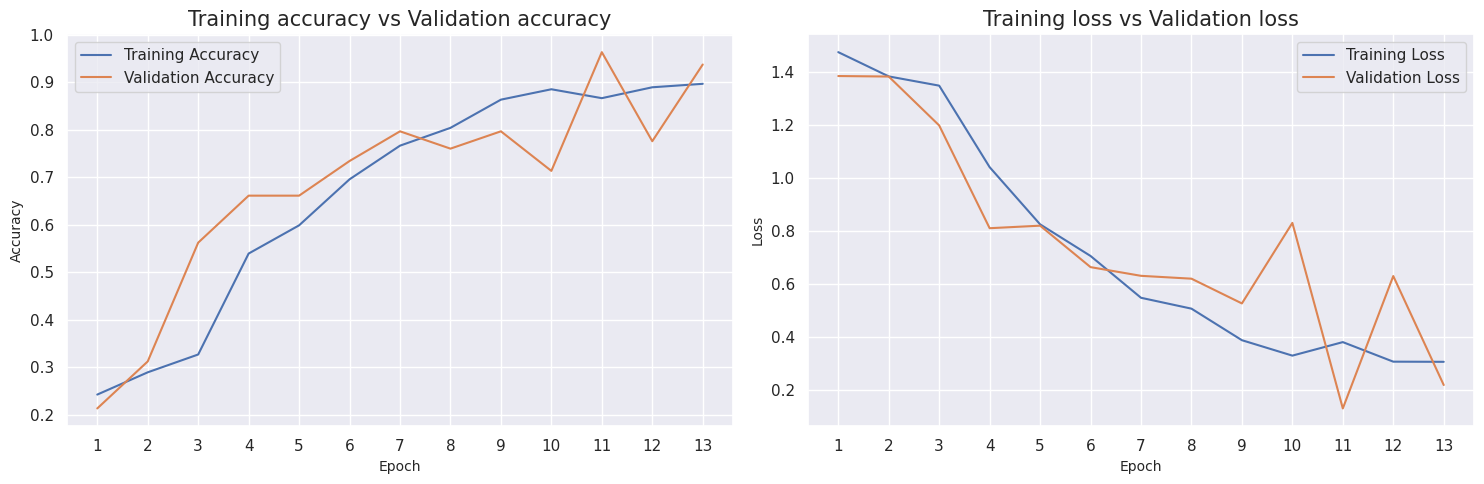

In [33]:
plot_results(history.history["accuracy"], history.history["loss"], history.history["val_accuracy"], history.history["val_loss"])

In [34]:
tf_model.evaluate(test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 424ms/step - accuracy: 0.9645 - loss: 0.1249


[0.20205333828926086, 0.9399999976158142]

In [54]:
y_t = []
for x, y in test_data:
  y_t.extend(y.numpy())

In [58]:
y_pred = []
for x, y in test_data:
  y_pred.extend(tf_model.predict(x).argmax(1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step


In [59]:
print(classification_report(y_t, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       100
           1       1.00      0.96      0.98       100
           2       0.91      1.00      0.95       100
           3       0.99      0.81      0.89       100

    accuracy                           0.94       400
   macro avg       0.95      0.94      0.94       400
weighted avg       0.95      0.94      0.94       400



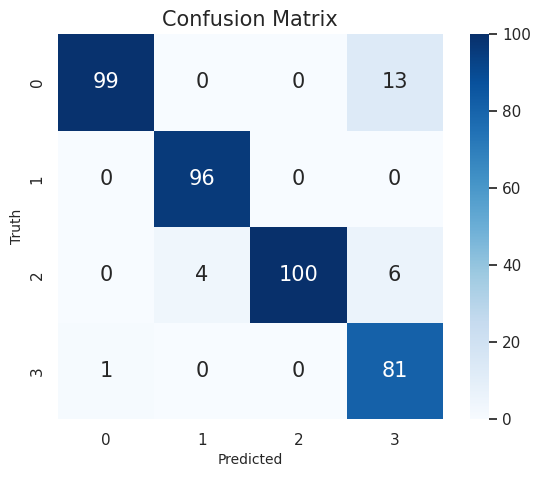

In [62]:
cm(y_t, y_pred)

In [103]:
torch.cuda.empty_cache()

In [104]:
resnet18 = models.resnet18(pretrained = True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [105]:
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 4)

In [106]:
resnet18 = resnet18.to(device)

  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Train Loss: 0.007 | Valid Loss: 0.020 | Train Acc: 99.722 | Valid Acc: 98.333: 100%|██████████| 10/10 [00:37<00:00,  3.78s/it]


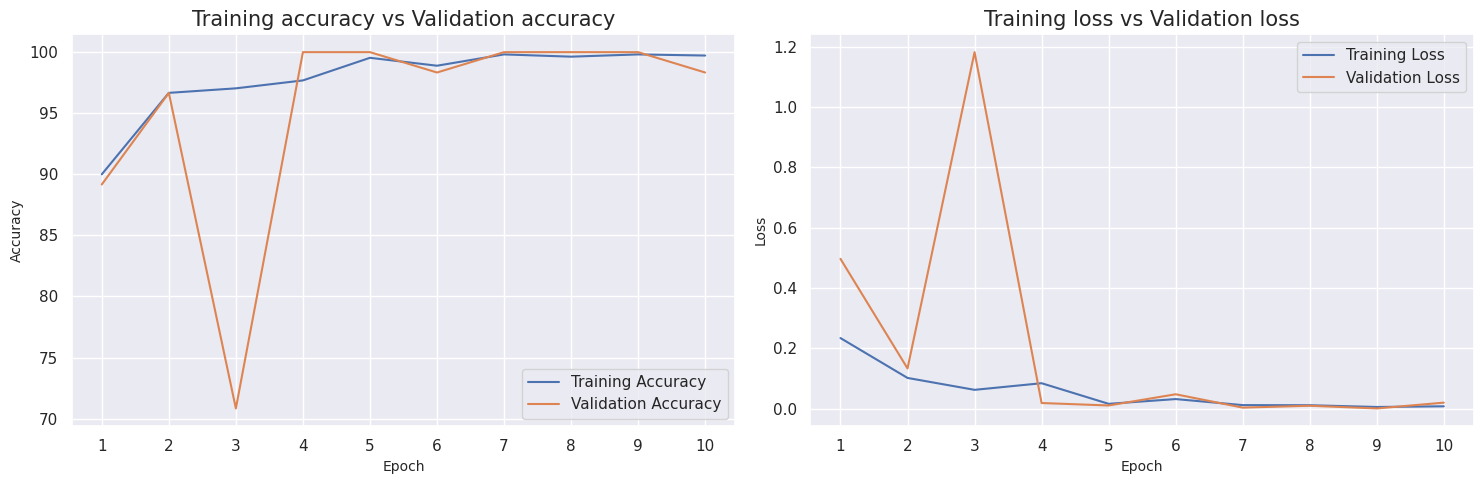

In [107]:
optimizer = torch.optim.Adam(resnet18.parameters(), lr = 0.001)
results = train_model(resnet18, 10, optimizer, train_loader, valid_loader, device = device)

In [111]:
resnet18.eval()
total_loss = 0
total_acc = 0
ac_y = []
pr_y = []
criterion = nn.CrossEntropyLoss()
with torch.no_grad():
  for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    preds = resnet18(x)
    total_loss += criterion(preds, y).item()
    total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
    ac_y.extend(y.cpu().numpy())
    pr_y.extend(preds.cpu().numpy())
test_loss = total_loss / len(test_loader)
test_acc = 100 * total_acc / len(test_loader.dataset)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Test Loss: 0.007
Test Accuracy: 99.750


In [115]:
pr = np.argmax(pr_y, axis = 1)

In [116]:
print(classification_report(ac_y, pr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      0.99      0.99       100
           3       0.99      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



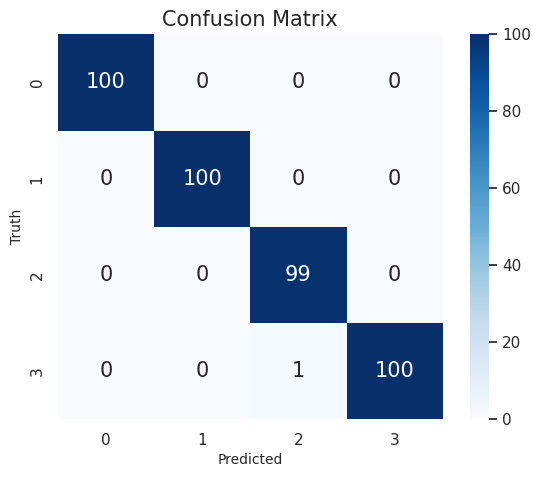

In [117]:
cm(ac_y, pr)

In [152]:
torch.cuda.empty_cache()

In [153]:
eff_net = EfficientNet.from_pretrained("efficientnet-b0")

Loaded pretrained weights for efficientnet-b0


In [154]:
for name, param in eff_net.named_parameters():
  param.requires_grad = False

for param in eff_net._fc.parameters():
  param.requires_grad = True

In [155]:
num_ftrs = eff_net._fc.in_features
eff_net._fc = nn.Linear(num_ftrs, 4)

Train Loss: 0.125 | Valid Loss: 0.128 | Train Acc: 96.852 | Valid Acc: 95.000: 100%|██████████| 20/20 [01:15<00:00,  3.76s/it]


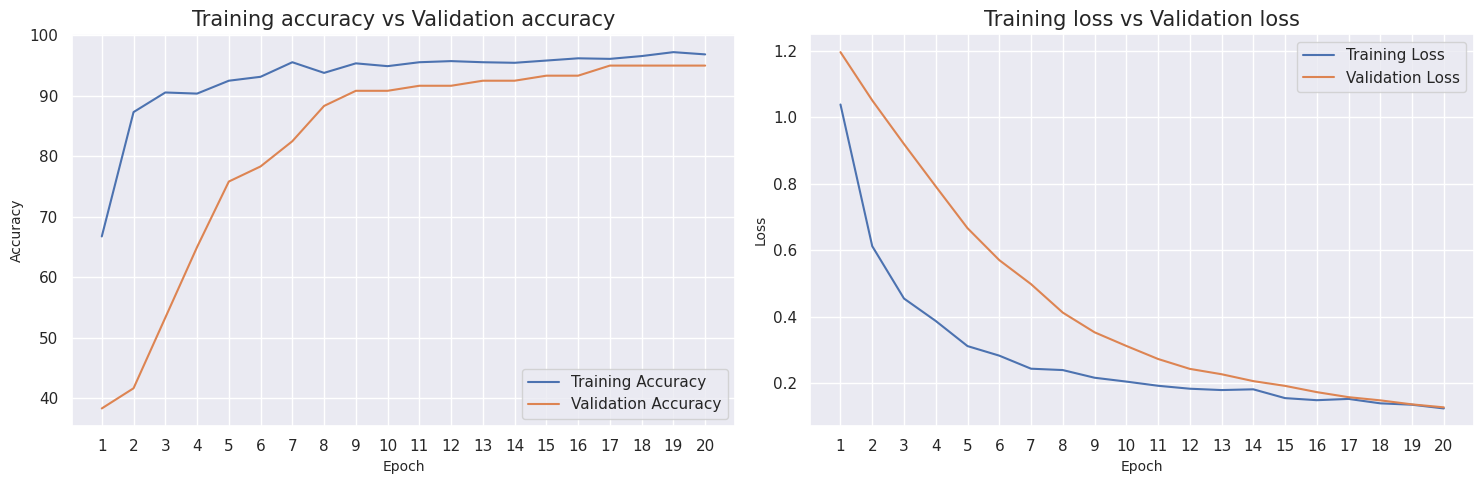

In [156]:
eff_net = eff_net.to(device)
optimizer = torch.optim.Adam(eff_net.parameters(), lr = 0.001)
results = train_model(eff_net, 20, optimizer, train_loader, valid_loader, device = device)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Test Loss: 0.104
Test Accuracy: 98.750


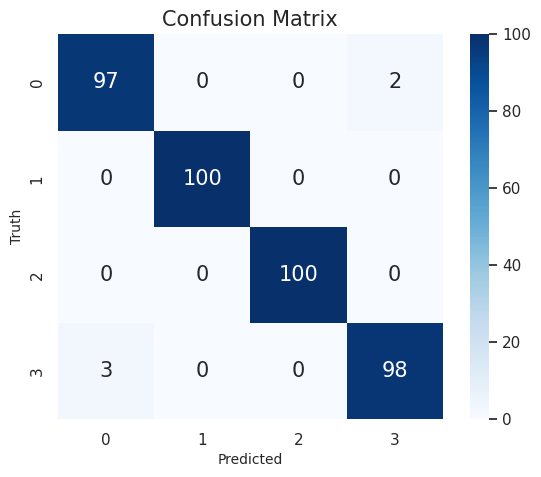

In [157]:
eff_net.eval()
total_loss = 0
total_acc = 0
y_p = []
y_t = []
criterion = nn.CrossEntropyLoss()
with torch.no_grad():
  for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    preds = eff_net(x)
    total_loss += criterion(preds, y).item()
    total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
    y_p.extend(preds.argmax(1).cpu().numpy())
    y_t.extend(y.cpu().numpy())
test_loss = total_loss / len(test_loader)
test_acc = 100 * total_acc / (len(test_loader.dataset))
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
cm(y_t, y_p)